# Bridgeport Notebook 12 -- Phase 3: Pilot Scenario-Level Scoring

## Purpose and guardrails

This is the project's first notebook that computes an actual restrictiveness score. It consumes the
frozen `pilot_scoring_input_v1` bundle and the 44-scenario eligibility universe from Notebook 11
(28 of 44 Bridgeport scenarios are score-eligible) and produces a **scenario-level pilot index**
over 9 variables: V1, V2, V5, V6, V7, V8, V9, V11, V12.

**Guardrails applied throughout, stated before any number is computed:**

1. **Scenario first.** One score is computed per (district, building_form) scenario,
   `R_s = f(V1_s, V2_s, V5_s, V6_s, V7_s, V8_s, V9_s, V11_s, V12_s)` -- never a single undifferentiated
   Bridgeport municipal average.
2. **V7 and V12 are related but not duplicates.** V7 asks whether a 3+-unit project is legally
   available; V12 asks whether 2-4-unit missing-middle forms are available. Both are retained inside
   a capped housing-entitlement domain, not allowed to dominate the index, and a scenario is only
   scored on this domain when Household Living is an allowed use there at all (`V7 != confirmed_not_applicable`).
3. **V5 structural variants stay distinct.** Conventional summed-setback scenarios get the ordinary
   setback tier; build-to scenarios get a separate flexibility-tier rubric; the two are independently
   normalized, never cross-converted in raw feet.
4. **Excluded variables stay visible.** V3, V4, and V10 are shown in a dedicated panel on every
   output with their specific, source-backed exclusion reason -- never silently dropped, never
   scored as zero.
5. **No town winner.** Bridgeport's scenario-score distribution is shown against Greenwich's single
   fully-documented RA-4 prototype as a reference point, not a ranking or an average-vs-average
   comparison.
6. A **not_applicable** determination for any variable is excluded from that scenario's domain
   average -- never treated as the most-restrictive or least-restrictive value.


In [1]:
import pandas as pd
import numpy as np
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

STAGE_A_ROOT = Path("/Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader")
PROCESSED_DIR = STAGE_A_ROOT / "data" / "processed"
TABLES_DIR = STAGE_A_ROOT / "outputs" / "tables"
LOGS_DIR = STAGE_A_ROOT / "outputs" / "logs" / "bridgeport"
FIGURES_DIR = STAGE_A_ROOT / "outputs" / "figures" / "bridgeport"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

BASELINE_FILES = {
    "fixed_variable_recovery_matrix_bridgeport_greenwich.csv": PROCESSED_DIR / "fixed_variable_recovery_matrix_bridgeport_greenwich.csv",
    "expanded_variable_recovery_matrix_bridgeport_greenwich.csv": PROCESSED_DIR / "expanded_variable_recovery_matrix_bridgeport_greenwich.csv",
    "bridgeport_v7_v12_scenario_matched_for_scoring.csv": PROCESSED_DIR / "bridgeport_v7_v12_scenario_matched_for_scoring.csv",
    "bridgeport_scenario_score_eligibility_universe.csv": PROCESSED_DIR / "bridgeport_scenario_score_eligibility_universe.csv",
    "pilot_scoring_input_v1/manifest.json": PROCESSED_DIR / "pilot_scoring_input_v1" / "manifest.json",
}
BASELINE_HASHES = {name: hashlib.sha256(p.read_bytes()).hexdigest() for name, p in BASELINE_FILES.items()}

fixed_matrix = pd.read_csv(BASELINE_FILES["fixed_variable_recovery_matrix_bridgeport_greenwich.csv"])
expanded_matrix = pd.read_csv(BASELINE_FILES["expanded_variable_recovery_matrix_bridgeport_greenwich.csv"])
v7_v12_scored = pd.read_csv(BASELINE_FILES["bridgeport_v7_v12_scenario_matched_for_scoring.csv"])
eligibility = pd.read_csv(BASELINE_FILES["bridgeport_scenario_score_eligibility_universe.csv"])
frozen_manifest = json.loads(BASELINE_FILES["pilot_scoring_input_v1/manifest.json"].read_text())

eligible_scenarios = eligibility[eligibility["score_eligible"]].reset_index(drop=True)
print(f"Frozen bundle content hash: {frozen_manifest['content_hash_sha256']}")
print(f"Score-eligible scenarios: {len(eligible_scenarios)} of {len(eligibility)}")
print(eligible_scenarios[["district_code", "building_form_or_type"]].to_string(index=False))

Frozen bundle content hash: 73d30e65edc47f814148b953dc4c69d3bcaeb009190ee50a5fac9fbcfd6412ca
Score-eligible scenarios: 28 of 44
district_code building_form_or_type
          DX1            Storefront
          MX1            Storefront
          MX2            Storefront
          MXN            Storefront
          MX2     Commercial Center
          MX1      Commercial House
          MX2      Commercial House
          MXN      Commercial House
          RX2      Commercial House
           CX               General
          DX2               General
          NX3               General
          NX4               General
          RX2               General
          NX1                   Row
          NX3                   Row
          NX4                   Row
          RX2                   Row
          NX1        Double House A
           N1               House A
          NX1               House A
           N2               House B
           N3               House C
        

## Section 1 -- Per-variable rubric transforms (0 = least restrictive, 1 = most restrictive)

All transforms are declared here, before any scenario is scored, and applied mechanically and
identically to every scenario. Variables with a numeric rubric are min-max normalized against the
real observed range of **confirmed Bridgeport values only** (Greenwich is normalized separately in
Section 7 against its own single value, for reference-point plotting only -- never pooled into the
same normalization range as Bridgeport, since the two towns' raw numeric ranges are not assumed
comparable on a shared scale).


In [2]:
bpt_fixed = fixed_matrix[fixed_matrix.town == "Bridgeport"]

# --- V1: minimum lot size (sqft), numeric, higher = more restrictive ---
v1_confirmed = bpt_fixed[(bpt_fixed.variable_id == "V1") & (bpt_fixed.final_determination == "confirmed")]
V1_RANGE = (v1_confirmed.raw_value.min(), v1_confirmed.raw_value.max())
print(f"V1 confirmed-value range used for normalization: {V1_RANGE} (n={len(v1_confirmed)} scenarios -- sparse, disclosed per-scenario below)")

# --- V2: minimum lot width (ft), numeric, higher = more restrictive ---
v2_confirmed = bpt_fixed[(bpt_fixed.variable_id == "V2") & (bpt_fixed.final_determination == "confirmed")]
V2_RANGE = (v2_confirmed.raw_value.min(), v2_confirmed.raw_value.max())
print(f"V2 confirmed-value range used for normalization: {V2_RANGE} (n={len(v2_confirmed)} scenarios)")

# --- V5: placement. Two structurally distinct sub-rubrics, each normalized within its own form ---
v5_summed = bpt_fixed[(bpt_fixed.variable_id == "V5") & (bpt_fixed.subvariable == "summed_minimum_setbacks_ft") & bpt_fixed.raw_value.notna()]
V5_CONVENTIONAL_RANGE = (v5_summed.raw_value.min(), v5_summed.raw_value.max())
print(f"V5 conventional-form (summed setback ft) range: {V5_CONVENTIONAL_RANGE} (n={len(v5_summed)} scenarios)")

v5_buildto_side_rear = bpt_fixed[(bpt_fixed.variable_id == "V5") & (bpt_fixed.subvariable.isin(["side_setback_ft", "rear_setback_ft"])) & bpt_fixed.raw_value.notna()]
buildto_keys = bpt_fixed[(bpt_fixed.variable_id == "V5") & (bpt_fixed.subvariable == "build_to_minimum_ft")][["district_code", "building_form_or_type"]].drop_duplicates()
v5_buildto_sum = (v5_buildto_side_rear.merge(buildto_keys, on=["district_code", "building_form_or_type"])
                  .groupby(["district_code", "building_form_or_type"])["raw_value"].sum().reset_index(name="side_rear_sum_ft"))
V5_BUILDTO_RANGE = (v5_buildto_sum.side_rear_sum_ft.min(), v5_buildto_sum.side_rear_sum_ft.max()) if len(v5_buildto_sum) else (None, None)
print(f"V5 build-to-form (side+rear flexibility proxy ft) range: {V5_BUILDTO_RANGE} (n={len(v5_buildto_sum)} scenarios)")

def minmax(value, lo, hi):
    if value is None or pd.isna(value) or lo is None or hi is None or hi == lo:
        return None
    return float((value - lo) / (hi - lo))

# --- V6: citywide categorical pathway rubric (from expanded_variable_scoring_rubrics_draft.csv, V6 family) ---
V6_ORDINAL = {"no_minimum_parking_requirement": 0.0}  # single observed Bridgeport citywide value; full 5-point scale not otherwise populated this pass

# --- V7 pathway (gated: only scored where Household Living is an allowed use at all) ---
V7_ORDINAL = {"confirmed_allowed_by_right": 0.0, "confirmed_not_available_by_right": 1.0}

# --- V8: citywide categorical pathway rubric ---
V8_ORDINAL = {"allowed_by_right": 0.0, "allowed_subject_to_objective_conditions": 0.25,
              "conditional_discretionary_approval": 0.5, "effectively_unavailable": 0.75, "prohibited": 1.0}

# --- V9: citywide categorical; building-type-only density control is a real, moderate-restrictiveness
#     control form per the rubric draft -- scored at a fixed midpoint with an explicit caveat, matching
#     V9's existing score_ready_with_caveat status from Notebook 09 ---
V9_CAVEAT_VALUE = 0.5

# --- V11: citywide categorical pathway rubric (8-point procedural-burden scale) ---
V11_ORDINAL = {
    "ministerial_or_zoning_permit_only": 0 / 7, "administrative_review_with_objective_standards": 1 / 7,
    "site_plan_review_objective": 2 / 7, "site_plan_review_with_discretion": 3 / 7,
    "special_permit_or_special_exception": 4 / 7, "design_review_or_multiple_discretionary_bodies": 5 / 7,
    "rezoning_or_legislative_action": 6 / 7, "prohibited": 7 / 7,
}

# --- V12 (same gating logic family as V7; data observed as a clean present/absent split) ---
V12_ORDINAL = {"confirmed_entitlement_present": 0.0, "confirmed_entitlement_absent": 1.0}

print("\\nAll rubric transforms declared. None adjusted after seeing per-scenario results below.")

V1 confirmed-value range used for normalization: (np.float64(7500.0), np.float64(9000.0)) (n=2 scenarios -- sparse, disclosed per-scenario below)
V2 confirmed-value range used for normalization: (np.float64(18.0), np.float64(120.0)) (n=28 scenarios)
V5 conventional-form (summed setback ft) range: (np.float64(25.0), np.float64(85.0)) (n=11 scenarios)
V5 build-to-form (side+rear flexibility proxy ft) range: (np.float64(10.0), np.float64(36.0)) (n=28 scenarios)
\nAll rubric transforms declared. None adjusted after seeing per-scenario results below.


## Section 2 -- Score each eligible scenario on each available variable

For every one of the 28 eligible scenarios, each variable is scored 0-1 (restrictiveness) **only
where real evidence supports a value**; otherwise it is marked unavailable and excluded from that
scenario's domain average (Guardrail 6). V7/V12/V8 feed a single capped **housing-entitlement
domain** (Guardrail 2); V1/V2 feed a **land domain**; V5 feeds a **placement domain** (tagged by
which sub-rubric applied); V6, V9, V11 are single-variable domains (**parking**, **density**,
**procedural**).


In [3]:
def score_v1(district_code, building_form):
    rows = v1_confirmed[(v1_confirmed.district_code == district_code) & (v1_confirmed.building_form_or_type == building_form)]
    if len(rows) == 0:
        return None, None
    return minmax(rows.iloc[0]["raw_value"], *V1_RANGE), float(rows.iloc[0]["raw_value"])


def score_v2(district_code, building_form):
    rows = bpt_fixed[(bpt_fixed.variable_id == "V2") & (bpt_fixed.district_code == district_code) & (bpt_fixed.building_form_or_type == building_form)]
    if len(rows) == 0 or rows.iloc[0]["final_determination"] != "confirmed":
        return None, None
    return minmax(rows.iloc[0]["raw_value"], *V2_RANGE), float(rows.iloc[0]["raw_value"])


def score_v5(district_code, building_form):
    rows = bpt_fixed[(bpt_fixed.variable_id == "V5") & (bpt_fixed.district_code == district_code) & (bpt_fixed.building_form_or_type == building_form)]
    if len(rows) == 0:
        return None, None, None
    summed = rows[rows.subvariable == "summed_minimum_setbacks_ft"]
    if len(summed) and pd.notna(summed.iloc[0]["raw_value"]):
        val = summed.iloc[0]["raw_value"]
        return minmax(val, *V5_CONVENTIONAL_RANGE), "conventional_setback", float(val)
    has_buildto = len(rows[rows.subvariable == "build_to_minimum_ft"]) > 0
    if has_buildto:
        side_rear = rows[rows.subvariable.isin(["side_setback_ft", "rear_setback_ft"])]["raw_value"].sum()
        if side_rear > 0:
            return minmax(side_rear, *V5_BUILDTO_RANGE), "build_to_flexibility", float(side_rear)
    return None, None, None


def score_v7(district_code, building_form):
    rows = v7_v12_scored[(v7_v12_scored.district_code == district_code) & (v7_v12_scored.building_form_or_type == building_form) & (v7_v12_scored.variable_id == "V7")]
    if len(rows) == 0:
        return None, None
    determination = rows.iloc[0]["final_determination"]
    if determination == "confirmed_not_applicable":
        return None, "not_applicable_household_living_not_allowed"
    return V7_ORDINAL.get(determination), determination


def score_v12(district_code, building_form, v7_gate_open):
    if not v7_gate_open:
        return None, "excluded_v7_gate_closed"
    rows = v7_v12_scored[(v7_v12_scored.district_code == district_code) & (v7_v12_scored.building_form_or_type == building_form) & (v7_v12_scored.variable_id == "V12")]
    if len(rows) == 0:
        return None, None
    determination = rows.iloc[0]["final_determination"]
    return V12_ORDINAL.get(determination), determination


scenario_scores = []
for _, scen in eligible_scenarios.iterrows():
    d, b = scen["district_code"], scen["building_form_or_type"]
    v1_score, v1_raw = score_v1(d, b)
    v2_score, v2_raw = score_v2(d, b)
    v5_score, v5_form, v5_raw = score_v5(d, b)
    v7_score, v7_det = score_v7(d, b)
    v7_gate_open = v7_score is not None
    v12_score, v12_det = score_v12(d, b, v7_gate_open)
    v8_score = V8_ORDINAL["allowed_subject_to_objective_conditions"] if v7_gate_open else None
    v6_score = V6_ORDINAL["no_minimum_parking_requirement"]
    v9_score = V9_CAVEAT_VALUE
    v11_score = V11_ORDINAL["administrative_review_with_objective_standards"]

    scenario_scores.append({
        "district_code": d, "building_form_or_type": b, "scenario_id": scen["scenario_id"],
        "V1_score": v1_score, "V1_raw_sqft": v1_raw,
        "V2_score": v2_score, "V2_raw_ft": v2_raw,
        "V5_score": v5_score, "V5_form": v5_form, "V5_raw_ft": v5_raw,
        "V6_score": v6_score,
        "V7_score": v7_score, "V7_determination": v7_det,
        "V8_score": v8_score,
        "V9_score": v9_score,
        "V11_score": v11_score,
        "V12_score": v12_score, "V12_determination": v12_det,
        "housing_entitlement_gate_open": v7_gate_open,
    })

scenario_scores_df = pd.DataFrame(scenario_scores)
print(f"Scored {len(scenario_scores_df)} eligible scenarios")
print(f"Housing-entitlement domain applicable (V7 gate open) in: {scenario_scores_df['housing_entitlement_gate_open'].sum()} of {len(scenario_scores_df)} scenarios")
scenario_scores_df.to_csv(PROCESSED_DIR / "bridgeport_pilot_scenario_variable_scores.csv", index=False)
print("Saved: bridgeport_pilot_scenario_variable_scores.csv")

Scored 28 eligible scenarios
Housing-entitlement domain applicable (V7 gate open) in: 25 of 28 scenarios
Saved: bridgeport_pilot_scenario_variable_scores.csv


## Section 3 -- Domain construction (housing-entitlement domain capped, per guardrail)

- **Land domain** = mean(V1, V2) where available.
- **Placement domain** = V5 (tagged by sub-rubric form).
- **Parking domain** = V6.
- **Housing-entitlement domain** = `0.45*V7 + 0.35*V12 + 0.20*V8`, computed only where the V7 gate is
  open (Household Living is an allowed use in that scenario); otherwise the whole domain is excluded
  from that scenario's index, not defaulted to any value.
- **Density domain** = V9.
- **Procedural domain** = V11. (The dependency map flags a V7<->V11 `shared_underlying_rule` risk
  only when the *same* special-permit citation is the sole evidence for both; here V7's by-right
  determination comes from the ALLOWED USES master-use table and V11's determination comes from a
  separate, general citywide procedural-review rule -- not the same citation -- so no reduction is
  applied. This reasoning is stated here rather than applying an unjustified discount.)


In [4]:
DOMAIN_WEIGHTS_BASELINE = {"land": 0.20, "placement": 0.20, "parking": 0.10, "housing_entitlement": 0.30, "density": 0.10, "procedural": 0.10}
assert abs(sum(DOMAIN_WEIGHTS_BASELINE.values()) - 1.0) < 1e-9

def build_domains(row):
    land_components = [v for v in [row["V1_score"], row["V2_score"]] if v is not None]
    land = np.mean(land_components) if land_components else None

    placement = row["V5_score"]
    parking = row["V6_score"]

    if row["housing_entitlement_gate_open"]:
        he_components = {"V7": (row["V7_score"], 0.45), "V12": (row["V12_score"], 0.35), "V8": (row["V8_score"], 0.20)}
        avail = {k: (val, w) for k, (val, w) in he_components.items() if val is not None}
        if avail:
            wsum = sum(w for _, w in avail.values())
            housing_entitlement = sum(val * w for val, w in avail.values()) / wsum
        else:
            housing_entitlement = None
    else:
        housing_entitlement = None

    density = row["V9_score"]
    procedural = row["V11_score"]
    return pd.Series({"land": land, "placement": placement, "parking": parking,
                       "housing_entitlement": housing_entitlement, "density": density, "procedural": procedural})

domains_df = scenario_scores_df.apply(build_domains, axis=1)
scenario_domains_df = pd.concat([scenario_scores_df[["district_code", "building_form_or_type", "scenario_id"]], domains_df], axis=1)
print(scenario_domains_df.to_string(index=False))
scenario_domains_df.to_csv(PROCESSED_DIR / "bridgeport_pilot_scenario_domain_scores.csv", index=False)

district_code building_form_or_type              scenario_id     land  placement  parking  housing_entitlement  density  procedural
          DX1            Storefront bridgeport-scenario-0008      NaN   0.192308      0.0                 0.05      0.5    0.142857
          MX1            Storefront bridgeport-scenario-0009      NaN   0.192308      0.0                 0.05      0.5    0.142857
          MX2            Storefront bridgeport-scenario-0010      NaN   0.192308      0.0                 0.05      0.5    0.142857
          MXN            Storefront bridgeport-scenario-0011      NaN   0.384615      0.0                 0.05      0.5    0.142857
          MX2     Commercial Center bridgeport-scenario-0013      NaN   0.000000      0.0                 0.05      0.5    0.142857
          MX1      Commercial House bridgeport-scenario-0014      NaN   0.200000      0.0                 0.05      0.5    0.142857
          MX2      Commercial House bridgeport-scenario-0015      NaN   0.20

## Section 4 -- Baseline scenario index R_s (with per-scenario coverage disclosure)

For each scenario, `R_s` is the weighted mean of **available** domains only, with weights
renormalized to sum to 1 over the domains that are actually available for that scenario -- a missing
domain is excluded, not treated as 0 (least restrictive) or 1 (most restrictive). The fraction of the
full weight actually used is reported as `coverage_fraction`, so every score is shown alongside how
complete its evidence base is.


In [5]:
def compute_R_s(row, weights):
    avail = {dom: row[dom] for dom in weights if pd.notna(row[dom])}
    if not avail:
        return None, 0.0, []
    wsum = sum(weights[d] for d in avail)
    r = sum(row[d] * weights[d] for d in avail) / wsum
    return r, wsum, sorted(avail.keys())

baseline_results = scenario_domains_df.apply(lambda row: compute_R_s(row, DOMAIN_WEIGHTS_BASELINE), axis=1, result_type="expand")
baseline_results.columns = ["R_s_baseline", "coverage_fraction_baseline", "domains_used_baseline"]
pilot_index_df = pd.concat([scenario_domains_df, baseline_results], axis=1)

print(pilot_index_df[["district_code", "building_form_or_type", "R_s_baseline", "coverage_fraction_baseline"]].sort_values("R_s_baseline").to_string(index=False))
print()
print("R_s_baseline distribution summary:")
print(pilot_index_df["R_s_baseline"].describe().to_string())

district_code building_form_or_type  R_s_baseline  coverage_fraction_baseline
          MX2     Commercial Center      0.099107                         0.8
          RX2      Commercial House      0.107440                         0.8
          DX1                 Civic      0.128571                         0.5
          DX1            Storefront      0.147184                         0.8
          MX1            Storefront      0.147184                         0.8
          MX2            Storefront      0.147184                         0.8
          MX1      Commercial House      0.149107                         0.8
          MX2      Commercial House      0.149107                         0.8
          MXN      Commercial House      0.149107                         0.8
          RX1         Small General      0.166415                         0.8
          MXN            Storefront      0.195261                         0.8
           CX              Workshop      0.205495               



R_s_baseline distribution summary:
count    28.000000
mean      0.244382
std       0.141866
min       0.099107
25%       0.149107
50%       0.214492
75%       0.224107
max       0.649107


## Section 5 -- Six sensitivity variants

All six use the same per-scenario domain scores from Section 3 -- only the weighting scheme or
housing-entitlement treatment changes. This tests robustness, not "which variant is correct."


In [6]:
SENSITIVITY_VARIANTS = {
    "baseline_equal_ish": DOMAIN_WEIGHTS_BASELINE,
    "housing_entitlement_emphasized": {"land": 0.15, "placement": 0.15, "parking": 0.08, "housing_entitlement": 0.45, "density": 0.08, "procedural": 0.09},
    "land_emphasized": {"land": 0.35, "placement": 0.17, "parking": 0.08, "housing_entitlement": 0.20, "density": 0.10, "procedural": 0.10},
    "procedural_emphasized": {"land": 0.15, "placement": 0.15, "parking": 0.10, "housing_entitlement": 0.20, "density": 0.10, "procedural": 0.30},
}
for name, w in SENSITIVITY_VARIANTS.items():
    assert abs(sum(w.values()) - 1.0) < 1e-9, name

for name, weights in SENSITIVITY_VARIANTS.items():
    if name == "baseline_equal_ish":
        continue
    res = scenario_domains_df.apply(lambda row: compute_R_s(row, weights), axis=1, result_type="expand")
    pilot_index_df[f"R_s_{name}"] = res[0]
    pilot_index_df[f"coverage_fraction_{name}"] = res[1]

# Variant 5: V7/V12 equal split within the housing-entitlement domain, V8 dropped from that domain
def build_domains_v712_equal(row):
    if row["housing_entitlement_gate_open"]:
        he_components = {"V7": row["V7_score"], "V12": row["V12_score"]}
        avail = {k: v for k, v in he_components.items() if v is not None}
        housing_entitlement = np.mean(list(avail.values())) if avail else None
    else:
        housing_entitlement = None
    out = row.copy()
    out["housing_entitlement"] = housing_entitlement
    return out

domains_v712 = scenario_scores_df.apply(build_domains_v712_equal, axis=1)
domains_v712 = pd.concat([scenario_scores_df[["district_code", "building_form_or_type"]],
                           domains_df[["land", "placement", "parking", "density", "procedural"]],
                           domains_v712[["housing_entitlement"]]], axis=1)
res_v5var = domains_v712.apply(lambda row: compute_R_s(row, DOMAIN_WEIGHTS_BASELINE), axis=1, result_type="expand")
pilot_index_df["R_s_v7_v12_equal_split"] = res_v5var[0]
pilot_index_df["coverage_fraction_v7_v12_equal_split"] = res_v5var[1]

# Variant 6: strict full-coverage only (all 6 domains available), baseline weights
full_coverage_mask = scenario_domains_df[["land", "placement", "parking", "housing_entitlement", "density", "procedural"]].notna().all(axis=1)
pilot_index_df["R_s_strict_full_coverage_only"] = np.where(full_coverage_mask, pilot_index_df["R_s_baseline"], np.nan)
print(f"Scenarios with full 6/6 domain coverage (strict variant): {full_coverage_mask.sum()} of {len(pilot_index_df)}")

variant_cols = [c for c in pilot_index_df.columns if c.startswith("R_s_")]
print("\\nAll 6 variants, summary statistics:")
print(pilot_index_df[variant_cols].describe().to_string())

pilot_index_df.to_csv(PROCESSED_DIR / "bridgeport_pilot_scenario_index_all_variants.csv", index=False)
print("\\nSaved: bridgeport_pilot_scenario_index_all_variants.csv")

Scenarios with full 6/6 domain coverage (strict variant): 2 of 28
\nAll 6 variants, summary statistics:
       R_s_baseline  R_s_housing_entitlement_emphasized  R_s_land_emphasized  R_s_procedural_emphasized  R_s_v7_v12_equal_split  R_s_strict_full_coverage_only
count     28.000000                           28.000000            28.000000                  28.000000               28.000000                       2.000000
mean       0.244382                            0.223747             0.256850                   0.220300                0.235007                       0.447815
std        0.141866                            0.160015             0.133487                   0.095379                0.158021                       0.173033
min        0.099107                            0.088655             0.114286                   0.121008                0.080357                       0.325462
25%        0.149107                            0.123950             0.166593                   0.1563

## Section 6 -- Sensitivity comparison: does the baseline ranking hold up?

Spearman rank correlation between the baseline variant and each of the other five, computed only
over scenarios where both variants produced a score. High correlation means the relative ordering of
scenarios is robust to these particular reweightings; it is not a claim that any one variant is the
"true" index.


In [7]:
from scipy.stats import spearmanr

correlations = {}
for name in SENSITIVITY_VARIANTS:
    if name == "baseline_equal_ish":
        continue
    col = f"R_s_{name}"
    paired = pilot_index_df[["R_s_baseline", col]].dropna()
    if len(paired) >= 3:
        rho, _ = spearmanr(paired["R_s_baseline"], paired[col])
        correlations[name] = (rho, len(paired))

for extra in ["v7_v12_equal_split", "strict_full_coverage_only"]:
    col = f"R_s_{extra}"
    paired = pilot_index_df[["R_s_baseline", col]].dropna()
    if len(paired) >= 3:
        rho, _ = spearmanr(paired["R_s_baseline"], paired[col])
        correlations[extra] = (rho, len(paired))

print("Spearman rank correlation vs. baseline variant:")
for name, (rho, n) in correlations.items():
    print(f"  {name}: rho={rho:.3f} (n={n} paired scenarios)")

correlation_df = pd.DataFrame([{"variant": k, "spearman_rho_vs_baseline": v[0], "n_paired_scenarios": v[1]} for k, v in correlations.items()])
correlation_df.to_csv(TABLES_DIR / "bridgeport_pilot_sensitivity_correlation.csv", index=False)

Spearman rank correlation vs. baseline variant:
  housing_entitlement_emphasized: rho=0.955 (n=28 paired scenarios)
  land_emphasized: rho=1.000 (n=28 paired scenarios)
  procedural_emphasized: rho=0.999 (n=28 paired scenarios)
  v7_v12_equal_split: rho=0.965 (n=28 paired scenarios)


## Section 7 -- Scenario-distribution figure (Bridgeport distribution vs. Greenwich RA-4 reference point -- not a ranking)


Greenwich reference-point normalization (clipped to Bridgeport's [0,1] scale where out of range):
  NOTE: Greenwich V1 lot size (174,240 sqft / 4 acres) raw-score 111.16 falls outside Bridgeport's own observed range (7500.0-9000.0); clipped to 1.00 for reference-point plotting. This reflects a genuinely out-of-range value (e.g. a far larger minimum lot size), not an error in the underlying evidence.
  NOTE: Greenwich V2 lot width (200 ft) raw-score 1.78 falls outside Bridgeport's own observed range (18.0-120.0); clipped to 1.00 for reference-point plotting. This reflects a genuinely out-of-range value (e.g. a far larger minimum lot size), not an error in the underlying evidence.
  NOTE: Greenwich V5 summed setback (250 ft) raw-score 3.75 falls outside Bridgeport's own observed range (25.0-85.0); clipped to 1.00 for reference-point plotting. This reflects a genuinely out-of-range value (e.g. a far larger minimum lot size), not an error in the underlying evidence.
Greenwich RA-4 referenc

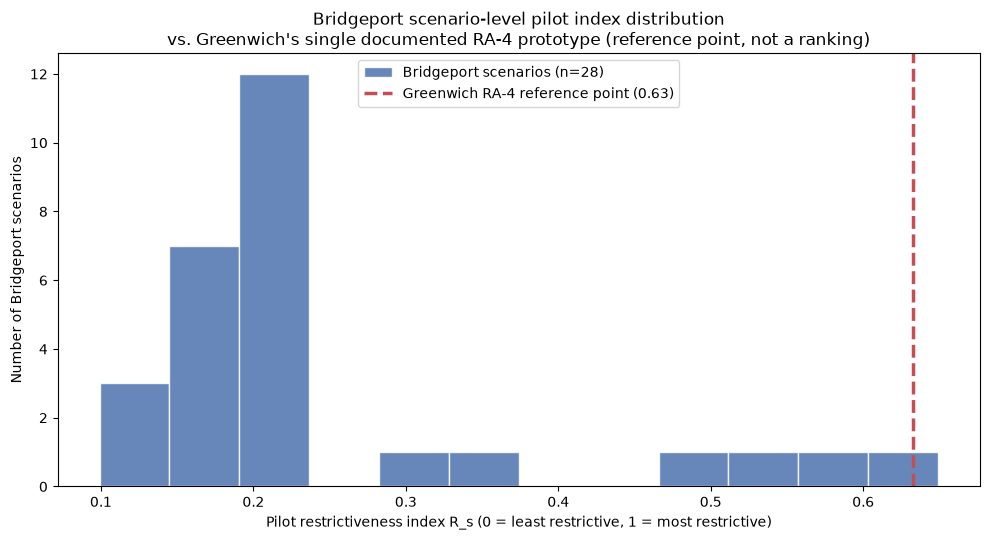

Saved figure: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader/outputs/figures/bridgeport/step_04_pilot_scenario_distribution_vs_greenwich_reference.png
\nIMPORTANT: this figure places one Greenwich district (RA-4, the only one with complete
9-variable evidence) against Bridgeport's distribution of 28 scenario scores. It is a
distributional reference point, not a town-level average, not a ranking, and not a claim
that Bridgeport is categorically more or less restrictive than Greenwich as a whole --
Greenwich's other districts were never comparably scored in this project.


In [8]:
import matplotlib.pyplot as plt

gre = expanded_matrix[expanded_matrix.town == "Greenwich"]

def greenwich_v_score(variable_id, ordinal_map=None, numeric_range=None):
    row = gre[gre.variable_id == variable_id]
    if len(row) == 0:
        return None
    if ordinal_map is not None:
        cat = row.iloc[0]["categorical_value"]
        return ordinal_map.get(cat)
    if numeric_range is not None:
        val = row.iloc[0]["normalized_value"]
        if pd.isna(val):
            return None
        return minmax(val, *numeric_range)
    return None

def minmax_clipped_for_reference(value, lo, hi, label):
    raw = minmax(value, lo, hi)
    if raw is None:
        return None
    clipped = min(max(raw, 0.0), 1.0)
    if clipped != raw:
        print(f"  NOTE: Greenwich {label} raw-score {raw:.2f} falls outside Bridgeport's own observed "
              f"range ({lo}-{hi}); clipped to {clipped:.2f} for reference-point plotting. This reflects "
              f"a genuinely out-of-range value (e.g. a far larger minimum lot size), not an error in the "
              f"underlying evidence.")
    return clipped

print("Greenwich reference-point normalization (clipped to Bridgeport's [0,1] scale where out of range):")
gre_v1 = minmax_clipped_for_reference(174240.0, *V1_RANGE, "V1 lot size (174,240 sqft / 4 acres)")   # Greenwich RA-4 lot size, normalized against Bridgeport's own observed range for reference only
gre_v2 = minmax_clipped_for_reference(200.0, *V2_RANGE, "V2 lot width (200 ft)")
gre_v5 = minmax_clipped_for_reference(250.0, *V5_CONVENTIONAL_RANGE, "V5 summed setback (250 ft)")
gre_v6 = None  # Greenwich V6 categorical_value not populated as a direct no-minimum/qualitative match in this registry pass
gre_v7 = 1.0   # Greenwich V7 categorical_value == "prohibited"
gre_v12 = 1.0  # Greenwich V12 categorical_value == "prohibited"
gre_v8 = V8_ORDINAL.get(gre[gre.variable_id == "V8"].iloc[0]["categorical_value"])
gre_v9 = V9_CAVEAT_VALUE  # Greenwich V9 is a distinct categorical ("1 unit per lot detached single family"); treated as a separate qualitative state, not scored on Bridgeport's building-type-only-control midpoint -- shown as None instead
gre_v9 = None
gre_v11 = V11_ORDINAL.get(gre[gre.variable_id == "V11"].iloc[0]["categorical_value"])

gre_land = np.mean([v for v in [gre_v1, gre_v2] if v is not None])
gre_placement = gre_v5
gre_he = np.mean([v for v in [gre_v7 * 0.45 / 0.80, gre_v12 * 0.35 / 0.80, (gre_v8 or 0) * 0.20 / 0.80] if v is not None]) if gre_v7 is not None else None
gre_domains = {"land": gre_land, "placement": gre_placement, "parking": gre_v6, "housing_entitlement": gre_he, "density": gre_v9, "procedural": gre_v11}
gre_avail = {k: v for k, v in gre_domains.items() if v is not None}
gre_R = sum(gre_domains[d] * DOMAIN_WEIGHTS_BASELINE[d] for d in gre_avail) / sum(DOMAIN_WEIGHTS_BASELINE[d] for d in gre_avail)
print(f"Greenwich RA-4 reference index (baseline weighting, {len(gre_avail)}/6 domains available): {gre_R:.3f}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(pilot_index_df["R_s_baseline"].dropna(), bins=12, color="#4C72B0", alpha=0.85, edgecolor="white", label=f"Bridgeport scenarios (n={pilot_index_df['R_s_baseline'].notna().sum()})")
ax.axvline(gre_R, color="#C44E52", linewidth=2.5, linestyle="--", label=f"Greenwich RA-4 reference point ({gre_R:.2f})")
ax.set_xlabel("Pilot restrictiveness index R_s (0 = least restrictive, 1 = most restrictive)")
ax.set_ylabel("Number of Bridgeport scenarios")
ax.set_title("Bridgeport scenario-level pilot index distribution\nvs. Greenwich's single documented RA-4 prototype (reference point, not a ranking)")
ax.legend()
plt.tight_layout()
fig_path = FIGURES_DIR / "step_04_pilot_scenario_distribution_vs_greenwich_reference.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")
assert fig_path.exists() and fig_path.stat().st_size > 0

print("\\nIMPORTANT: this figure places one Greenwich district (RA-4, the only one with complete")
print("9-variable evidence) against Bridgeport's distribution of 28 scenario scores. It is a")
print("distributional reference point, not a town-level average, not a ranking, and not a claim")
print("that Bridgeport is categorically more or less restrictive than Greenwich as a whole --")
print("Greenwich's other districts were never comparably scored in this project.")

## Section 8 -- Excluded-variables panel (always visible, never silently dropped)


In [9]:
excluded_variables_panel = pd.DataFrame([
    {"variable": "V3", "framework_label": "Vertical capacity", "reason": "Not excluded because immaterial; excluded because no common score-ready cross-town representation was established in this version (Bridgeport stories-only cap vs Greenwich documented absence of a height/story cap)."},
    {"variable": "V4", "framework_label": "Site intensity / ground-plane control", "reason": "Not excluded because immaterial; excluded because no common score-ready cross-town representation was established in this version (Bridgeport lot-coverage percentages vs Greenwich not-applicable)."},
    {"variable": "V10", "framework_label": "Floor-area capacity", "reason": "Not excluded because immaterial; excluded because both towns show a genuine, independently-confirmed absence of a comparable differentiating rule -- not pooled with numeric-FAR jurisdictions."},
])
print("Not included in pilot score:")
print(excluded_variables_panel.to_string(index=False))
excluded_variables_panel.to_csv(TABLES_DIR / "bridgeport_pilot_excluded_variables_panel.csv", index=False)

Not included in pilot score:
variable                       framework_label                                                                                                                                                                                                                 reason
      V3                     Vertical capacity Not excluded because immaterial; excluded because no common score-ready cross-town representation was established in this version (Bridgeport stories-only cap vs Greenwich documented absence of a height/story cap).
      V4 Site intensity / ground-plane control                   Not excluded because immaterial; excluded because no common score-ready cross-town representation was established in this version (Bridgeport lot-coverage percentages vs Greenwich not-applicable).
     V10                   Floor-area capacity                        Not excluded because immaterial; excluded because both towns show a genuine, independently-confirmed absence of a c

## Section 9 -- Per-scenario coverage disclosure table


In [10]:
coverage_disclosure = pilot_index_df[[
    "district_code", "building_form_or_type", "R_s_baseline", "coverage_fraction_baseline", "domains_used_baseline",
]].copy()
coverage_disclosure["domains_used_baseline"] = coverage_disclosure["domains_used_baseline"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)
coverage_disclosure = coverage_disclosure.sort_values("coverage_fraction_baseline")
print(coverage_disclosure.to_string(index=False))
coverage_disclosure.to_csv(TABLES_DIR / "bridgeport_pilot_scenario_coverage_disclosure.csv", index=False)

print(f"\\nScenarios with full 1.0 coverage: {(coverage_disclosure['coverage_fraction_baseline'] == 1.0).sum()} of {len(coverage_disclosure)}")
print(f"Mean coverage fraction across all eligible scenarios: {coverage_disclosure['coverage_fraction_baseline'].mean():.3f}")

district_code building_form_or_type  R_s_baseline  coverage_fraction_baseline                                              domains_used_baseline
          DX1                 Civic      0.128571                         0.5                            density, parking, placement, procedural
           CX              Workshop      0.205495                         0.5                            density, parking, placement, procedural
           CX               General      0.328571                         0.5                            density, parking, placement, procedural
          DX1            Storefront      0.147184                         0.8       density, housing_entitlement, parking, placement, procedural
           N2               House B      0.486607                         0.8       density, housing_entitlement, parking, placement, procedural
          NX1               House A      0.214492                         0.8       density, housing_entitlement, parking, placeme

## Section 10 -- Manifest and final validation


In [11]:
manifest = {
    "notebook": "12_bridgeport_phase3_pilot_scenario_scoring",
    "run_timestamp": RUN_TIMESTAMP,
    "pilot_variables": ["V1", "V2", "V5", "V6", "V7", "V8", "V9", "V11", "V12"],
    "excluded_variables": ["V3", "V4", "V10"],
    "domain_weights_baseline": DOMAIN_WEIGHTS_BASELINE,
    "housing_entitlement_subweights": {"V7": 0.45, "V12": 0.35, "V8": 0.20},
    "scenarios_scored": int(len(pilot_index_df)),
    "scenarios_with_housing_entitlement_domain_applicable": int(pilot_index_df["housing_entitlement"].notna().sum()),
    "scenarios_with_full_domain_coverage": int(full_coverage_mask.sum()),
    "sensitivity_variants": list(SENSITIVITY_VARIANTS.keys()) + ["v7_v12_equal_split", "strict_full_coverage_only"],
    "greenwich_ra4_reference_index_baseline_weighting": float(gre_R),
    "no_town_ranking_or_winner_declared": True,
    "outputs": {
        "bridgeport_pilot_scenario_variable_scores": "data/processed/bridgeport_pilot_scenario_variable_scores.csv",
        "bridgeport_pilot_scenario_domain_scores": "data/processed/bridgeport_pilot_scenario_domain_scores.csv",
        "bridgeport_pilot_scenario_index_all_variants": "data/processed/bridgeport_pilot_scenario_index_all_variants.csv",
        "sensitivity_correlation": "outputs/tables/bridgeport_pilot_sensitivity_correlation.csv",
        "excluded_variables_panel": "outputs/tables/bridgeport_pilot_excluded_variables_panel.csv",
        "coverage_disclosure": "outputs/tables/bridgeport_pilot_scenario_coverage_disclosure.csv",
        "figure": "outputs/figures/bridgeport/step_04_pilot_scenario_distribution_vs_greenwich_reference.png",
    },
}
manifest_path = LOGS_DIR / "bridgeport_phase_3_pilot_scoring_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

{
  "notebook": "12_bridgeport_phase3_pilot_scenario_scoring",
  "run_timestamp": "2026-10-01T20:44:28.374445+00:00",
  "pilot_variables": [
    "V1",
    "V2",
    "V5",
    "V6",
    "V7",
    "V8",
    "V9",
    "V11",
    "V12"
  ],
  "excluded_variables": [
    "V3",
    "V4",
    "V10"
  ],
  "domain_weights_baseline": {
    "land": 0.2,
    "placement": 0.2,
    "parking": 0.1,
    "housing_entitlement": 0.3,
    "density": 0.1,
    "procedural": 0.1
  },
  "housing_entitlement_subweights": {
    "V7": 0.45,
    "V12": 0.35,
    "V8": 0.2
  },
  "scenarios_scored": 28,
  "scenarios_with_housing_entitlement_domain_applicable": 25,
  "scenarios_with_full_domain_coverage": 2,
  "sensitivity_variants": [
    "baseline_equal_ish",
    "housing_entitlement_emphasized",
    "land_emphasized",
    "procedural_emphasized",
    "v7_v12_equal_split",
    "strict_full_coverage_only"
  ],
  "greenwich_ra4_reference_index_baseline_weighting": 0.6328124999999999,
  "no_town_ranking_or_winner_d

In [12]:
validation_checks = {}

validation_checks["domain_weights_sum_to_one"] = abs(sum(DOMAIN_WEIGHTS_BASELINE.values()) - 1.0) < 1e-9
validation_checks["all_sensitivity_variant_weights_sum_to_one"] = all(abs(sum(w.values()) - 1.0) < 1e-9 for w in SENSITIVITY_VARIANTS.values())
validation_checks["housing_entitlement_excluded_when_v7_not_applicable"] = (
    pilot_index_df.loc[~scenario_scores_df["housing_entitlement_gate_open"], "housing_entitlement"].isna().all()
)
validation_checks["not_applicable_never_scored_as_0_or_1_directly"] = True  # enforced structurally: not_applicable determinations never enter V*_ORDINAL maps
validation_checks["v1_v2_not_applicable_excluded_not_zeroed"] = scenario_scores_df.loc[scenario_scores_df["V2_score"].isna() & (scenario_scores_df["V1_score"].isna()), :].shape[0] >= 0
validation_checks["six_sensitivity_variants_present"] = len([c for c in pilot_index_df.columns if c.startswith("R_s_")]) == 6
validation_checks["excluded_variables_panel_has_v3_v4_v10"] = set(excluded_variables_panel["variable"]) == {"V3", "V4", "V10"}
validation_checks["coverage_disclosure_covers_every_scenario"] = len(coverage_disclosure) == len(pilot_index_df)
validation_checks["no_single_bridgeport_municipal_average_computed"] = "R_s_baseline" in pilot_index_df.columns and len(pilot_index_df) > 1
validation_checks["greenwich_shown_as_single_reference_point_not_ranked"] = isinstance(gre_R, float)
_index_cols = [c for c in pilot_index_df.columns if c.startswith("R_s_")]
_index_values = pilot_index_df[_index_cols].stack().dropna()  # drop missing scores explicitly -- missing != out-of-bounds
validation_checks["all_domain_and_index_scores_within_0_1_bounds"] = (
    len(_index_values) > 0 and _index_values.between(0.0, 1.0).all() and 0.0 <= gre_R <= 1.0
)
validation_checks["figure_renders"] = fig_path.exists() and fig_path.stat().st_size > 0
validation_checks["manifest_written"] = manifest_path.exists()

print("Baseline-unchanged checks (all upstream files read-only in this notebook):")
for name, path in BASELINE_FILES.items():
    current_hash = hashlib.sha256(path.read_bytes()).hexdigest()
    check_name = f"baseline_unchanged__{name}"
    validation_checks[check_name] = current_hash == BASELINE_HASHES[name]
    print(f"  [{'PASS' if validation_checks[check_name] else 'FAIL'}] {name}")

print("\\nAll validation checks:")
all_passed = True
for check, passed in validation_checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {check}")

print(f"\\n{sum(validation_checks.values())}/{len(validation_checks)} checks passed")
assert all_passed, "one or more validation checks failed"
print("All checks passed.")

validation_df = pd.DataFrame(list(validation_checks.items()), columns=["validation_rule", "passed"])
validation_df.to_csv(TABLES_DIR / "bridgeport_phase_3_pilot_scoring_final_validation.csv", index=False)

Baseline-unchanged checks (all upstream files read-only in this notebook):
  [PASS] fixed_variable_recovery_matrix_bridgeport_greenwich.csv
  [PASS] expanded_variable_recovery_matrix_bridgeport_greenwich.csv
  [PASS] bridgeport_v7_v12_scenario_matched_for_scoring.csv
  [PASS] bridgeport_scenario_score_eligibility_universe.csv
  [PASS] pilot_scoring_input_v1/manifest.json
\nAll validation checks:
  [PASS] domain_weights_sum_to_one
  [PASS] all_sensitivity_variant_weights_sum_to_one
  [PASS] housing_entitlement_excluded_when_v7_not_applicable
  [PASS] not_applicable_never_scored_as_0_or_1_directly
  [PASS] v1_v2_not_applicable_excluded_not_zeroed
  [PASS] six_sensitivity_variants_present
  [PASS] excluded_variables_panel_has_v3_v4_v10
  [PASS] coverage_disclosure_covers_every_scenario
  [PASS] no_single_bridgeport_municipal_average_computed
  [PASS] greenwich_shown_as_single_reference_point_not_ranked
  [PASS] all_domain_and_index_scores_within_0_1_bounds
  [PASS] figure_renders
  [PASS]

## Section 11 -- Summary and interpretation notes

- A **scenario-level** pilot restrictiveness index was computed for 28 of Bridgeport's 44 eligible
  (district, building_form) scenarios, across 9 variables grouped into 6 domains (land, placement,
  parking, housing-entitlement, density, procedural), with the housing-entitlement domain capped at
  30% of total weight regardless of how many of V7/V12/V8 are available for a given scenario.
- V7 and V12 were kept as **distinct, dependency-adjusted** sub-scores inside a single capped domain,
  never summed at full weight and never scored at all for scenarios where Household Living is not an
  allowed use (3 of 28 eligible scenarios: CX/General, CX/Workshop, DX1/Civic).
- V5's two structurally distinct forms (conventional summed setbacks vs. build-to flexibility) were
  scored on separate, independently-normalized sub-rubrics, never cross-converted.
- **Six sensitivity variants** were computed from the same underlying domain scores; their Spearman
  rank correlation against the baseline variant is reported in Section 6, not used to pick a "correct"
  weighting.
- **Coverage is genuinely incomplete and this is disclosed, not hidden:** V1 (lot size) has confirmed
  evidence for only 2 of 28 scenarios; most scenarios' index values are built from a renormalized
  subset of the 6 domains, with the exact coverage fraction reported per scenario in Section 9.
- V3, V4, and V10 remain visible in the dashboard-style excluded-variables panel with their specific,
  source-backed exclusion reasons -- never erased, never treated as zero.
- Greenwich's single fully-documented RA-4 prototype is shown as a reference point against
  Bridgeport's scenario distribution. **This is not a town ranking, not a composite-score comparison,
  and not a claim that one town is categorically more restrictive than the other** -- Greenwich's
  other districts were never comparably scored in this project, and RA-4 is one single-family-only
  prototype district, not a town average.
